In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('cleaned_data.csv')

In [14]:
stars = ["Star1", "Star2", "Star3", "Star4"]

top_20_stars = (
    df.melt(id_vars="gross_category", value_vars=stars, value_name="Star")
      .dropna(subset=["Star"])
      .groupby("Star")
      .agg(
          Total_Movie_Count=("Star", "size"),
          Low=("gross_category", lambda x: (x == "Low").sum()),
          Moderate=("gross_category", lambda x: (x == "Moderate").sum()),
          High=("gross_category", lambda x: (x == "High").sum()),
          Blockbuster=("gross_category", lambda x: (x == "Blockbuster").sum())
      )
      .sort_values("Total_Movie_Count", ascending=False)
      .head(20)
      .reset_index()
)

top_20_stars["Hit_Coefficient"] = (
    (top_20_stars["High"] + top_20_stars["Blockbuster"])
    / top_20_stars["Total_Movie_Count"]
).map(lambda x: f"{x:.1%}")

top_20_stars

,Star,Total_Movie_Count,Low,Moderate,High,Blockbuster,Hit_Coefficient
0,Robert De Niro,17,4,7,4,2,35.3%
1,Al Pacino,13,1,7,4,1,38.5%
2,Tom Hanks,13,0,0,2,11,100.0%
3,Brad Pitt,12,0,3,4,5,75.0%
4,Leonardo DiCaprio,11,1,0,1,9,90.9%
5,Matt Damon,11,0,1,0,10,90.9%
6,Clint Eastwood,11,2,5,1,3,36.4%
7,Christian Bale,11,1,2,4,4,72.7%
8,Johnny Depp,9,3,2,3,1,44.4%
9,Scarlett Johansson,9,2,3,1,3,44.4%


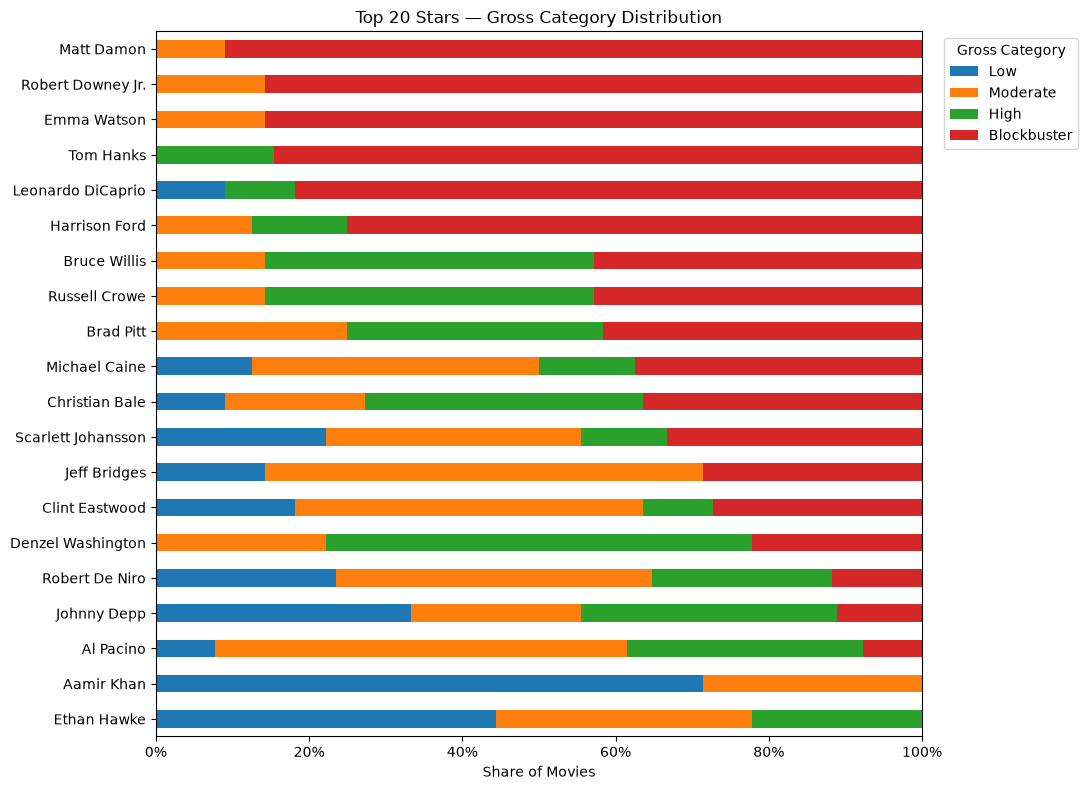

In [15]:
import matplotlib.ticker as mtick

plot_df = top_20_stars.copy()

cols = ["Low", "Moderate", "High", "Blockbuster"]
plot_df[cols] = plot_df[cols].div(
    plot_df["Total_Movie_Count"], axis=0
)

plot_df = plot_df.sort_values("Blockbuster")

ax = plot_df.set_index("Star")[cols].plot(
    kind="barh",
    stacked=True,
    figsize=(11, 8)
)

ax.set_xlabel("Share of Movies")
ax.set_ylabel("")
ax.set_title("Top 20 Stars — Gross Category Distribution")

ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))
ax.legend(title="Gross Category", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()